In [1]:
# Rewritten evaluation code for universal band support
import os
import time
import numpy as np
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path
import matplotlib.pyplot as plt
from glob import glob

from rfml_uav.drone_rf.consts import BUI, FS_HZ, get_bui_name
from rfml_uav.drone_rf.utils import get_segment_count, get_binary_label
from sklearn.metrics import roc_curve, auc, confusion_matrix

from rfml_uav.signal_detection.methods import (
    energy_detector,
    wavelet_detector,
    cyclo_detector,
)
from rfml_uav.signal_detection.cascade import cascade_detector

assert FS_HZ > 1e6, "Sampling rate must be specified in Hz"

OUT = Path("../../results/review_1")
OUT.mkdir(parents=True, exist_ok=True)

In [2]:
load_dotenv()
CHUNKED_PATH = Path(os.getenv("DATA_PATH")) / "chunked"

np.random.seed(42)

BASELINE_DETECTORS = {
    "Energy": lambda x: energy_detector(x),
    "Wavelet": lambda x: wavelet_detector(x),
    "Cyclo (blind)": lambda x: cyclo_detector(x, fs=FS_HZ),
}


In [3]:
def estimate_energy_threshold_bg(chunked_path, buis_bg, pfa=0.05):
    bg_scores = []
    for bui in buis_bg:
        for seg in range(get_segment_count(bui)):
            files = sorted(glob(str(chunked_path / f"{bui}*_{seg}.npz")))
            for file_path in files:
                chunks = np.load(file_path)["arr_0"]
                for x in chunks:
                    bg_scores.append(energy_detector(x))
    return np.percentile(bg_scores, 100 * (1 - pfa))

thr_energy = estimate_energy_threshold_bg(CHUNKED_PATH, buis_bg=["00000"], pfa=0.05)

def duration_constrained_score(scores, fs_hz, chunk_len, min_duration=0.1):
    if len(scores) == 0:
        return 0.0
    chunk_dur = chunk_len / fs_hz
    k = max(1, int(np.ceil(min_duration / chunk_dur)))
    if len(scores) < k:
        return np.mean(scores)
    return np.mean(np.sort(scores)[-k:])

In [4]:
chunk_scores = {name: [] for name in BASELINE_DETECTORS}
chunk_labels = []
segment_scores = {name: [] for name in BASELINE_DETECTORS}
segment_scores["Cascade"] = []
segment_labels = []

cascade_stats = {
    "segments_total": 0,
    "segments_signal": 0,
    "segments_noise": 0,
    "segments_cyclo": 0,
    "segments_cyclo_signal": 0,
    "segments_cyclo_noise": 0,
    "bursts_per_segment": [],
    "burst_lengths": [],
}

timings = {k: [] for k in [
    "Energy", "Wavelet", "Cyclo (blind)",
    "Cascade_stage1", "Cascade_aggregation", "Cascade_cyclo", "Cascade_total"]}

In [5]:
MIN_BURST_LEN = 50

pbar = tqdm(BUI, desc="Evaluation")
for bui in pbar:
    label = get_binary_label(bui)
    for seg in range(get_segment_count(bui)):
        pbar.set_postfix(bui=bui, name=get_bui_name(bui), segment=seg)

        seg_scores = {name: [] for name in BASELINE_DETECTORS}
        cascade_scores = []
        t_energy = t_wavelet = t_cyclo = 0.0
        c_stage1 = c_agg = c_cyclo = 0.0

        files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
        if not files:
            continue

        cyclo_invoked_flag = False

        for file_path in files:
            data = np.load(file_path)["arr_0"]
            chunk_len = len(data[0])

            for x in data:
                chunk_scores["Energy"].append(energy_detector(x))
                chunk_scores["Wavelet"].append(wavelet_detector(x))
                chunk_scores["Cyclo (blind)"].append(cyclo_detector(x, fs=FS_HZ))
                chunk_labels.append(label)

            t0 = time.perf_counter()
            seg_scores["Energy"].extend([energy_detector(x) for x in data])
            t_energy += time.perf_counter() - t0

            t0 = time.perf_counter()
            seg_scores["Wavelet"].extend([wavelet_detector(x) for x in data])
            t_wavelet += time.perf_counter() - t0

            t0 = time.perf_counter()
            seg_scores["Cyclo (blind)"].extend([cyclo_detector(x, fs=FS_HZ) for x in data])
            t_cyclo += time.perf_counter() - t0

            c_score, c_time, c_meta = cascade_detector(
                chunks=data, fs=FS_HZ, thr=thr_energy, min_burst_len=MIN_BURST_LEN, return_meta=True)

            if c_meta["cyclo_invoked"]:
                cyclo_invoked_flag = True
                n_bursts = len(c_meta["bursts"])
                cascade_stats["bursts_per_segment"].append(n_bursts)
                for b0, b1 in c_meta["bursts"]:
                    cascade_stats["burst_lengths"].append(b1 - b0)

            cascade_scores.append(c_score)
            c_stage1 += c_time["stage1"]
            c_agg += c_time["aggregation"]
            c_cyclo += c_time["cyclo"]

        if not seg_scores["Energy"]:
            continue

        cascade_stats["segments_total"] += 1
        if label == 1:
            cascade_stats["segments_signal"] += 1
        else:
            cascade_stats["segments_noise"] += 1

        if cyclo_invoked_flag:
            cascade_stats["segments_cyclo"] += 1
            if label == 1:
                cascade_stats["segments_cyclo_signal"] += 1
            else:
                cascade_stats["segments_cyclo_noise"] += 1

        segment_scores["Energy"].append(duration_constrained_score(seg_scores["Energy"], FS_HZ, chunk_len))
        segment_scores["Wavelet"].append(duration_constrained_score(seg_scores["Wavelet"], FS_HZ, chunk_len))
        segment_scores["Cyclo (blind)"].append(duration_constrained_score(seg_scores["Cyclo (blind)"], FS_HZ, chunk_len))
        segment_scores["Cascade"].append(max(cascade_scores))
        segment_labels.append(label)

        timings["Energy"].append(t_energy)
        timings["Wavelet"].append(t_wavelet)
        timings["Cyclo (blind)"].append(t_cyclo)
        timings["Cascade_stage1"].append(c_stage1)
        timings["Cascade_aggregation"].append(c_agg)
        timings["Cascade_cyclo"].append(c_cyclo)
        timings["Cascade_total"].append(c_stage1 + c_agg + c_cyclo)

# Convert lists to arrays
chunk_labels = np.asarray(chunk_labels)
segment_labels = np.asarray(segment_labels)
chunk_scores = {k: np.asarray(v) for k, v in chunk_scores.items()}
segment_scores = {k: np.asarray(v) for k, v in segment_scores.items()}
timings = {k: np.asarray(v) for k, v in timings.items()}

Evaluation: 100%|██████████| 10/10 [20:46<00:00, 124.70s/it, bui=11000, name=Phantom, segment=20]  


In [6]:
print("\nAverage execution time per segment:")
for k, v in timings.items():
    print(f"{k:22s}: {np.mean(v)*1e3:.2f} ms")


Average execution time per segment:
Energy                : 18.96 ms
Wavelet               : 173.20 ms
Cyclo (blind)         : 2060.96 ms
Cascade_stage1        : 19.09 ms
Cascade_aggregation   : 0.10 ms
Cascade_cyclo         : 824.71 ms
Cascade_total         : 843.90 ms


In [7]:
def metrics_at_pfa(y, s, target_pfa=0.05):
    fpr, tpr, thr = roc_curve(y, s)
    ok = np.where(fpr <= target_pfa)[0]
    i = ok[np.argmax(tpr[ok])] if len(ok) else np.argmin(fpr)

    y_hat = (s >= thr[i]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_hat).ravel()

    return {
        "AUC": auc(fpr, tpr),
        "Pd": tp / (tp + fn),
        "Pfa": fp / (fp + tn),
    }

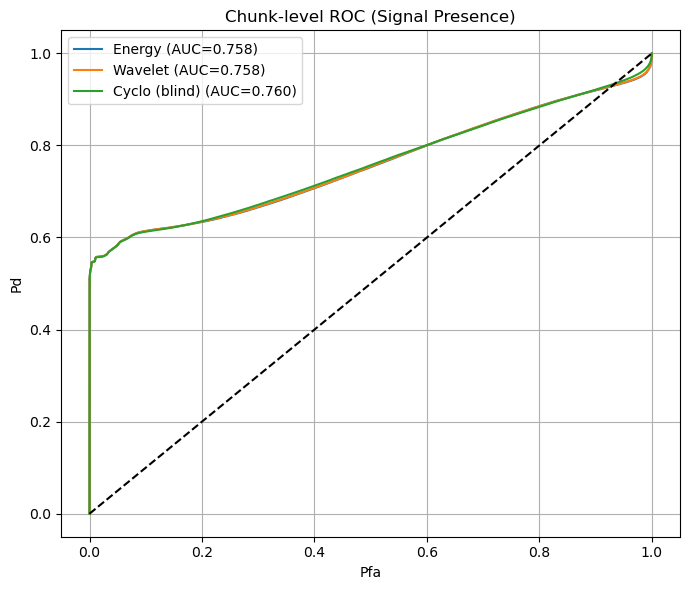

In [8]:
plt.figure(figsize=(7, 6))
for name, s in chunk_scores.items():
    fpr, tpr, _ = roc_curve(chunk_labels, s)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("Pfa")
plt.ylabel("Pd")
plt.title("Chunk-level ROC (Signal Presence)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT / "main_roc_chunk.png", dpi=150)
plt.show()

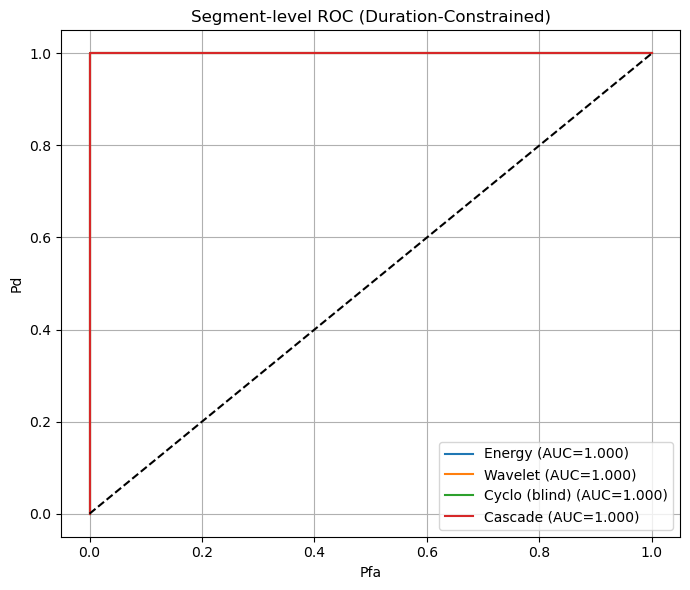

In [9]:
plt.figure(figsize=(7, 6))
for name, s in segment_scores.items():
    fpr, tpr, _ = roc_curve(segment_labels, s)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("Pfa")
plt.ylabel("Pd")
plt.title("Segment-level ROC (Duration-Constrained)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT / "main_roc_segment.png", dpi=150)
plt.show()

In [10]:
print("\nSegment-level Pd@Pfa=0.05:")
for name, s in segment_scores.items():
    m = metrics_at_pfa(segment_labels, s, target_pfa=0.05)
    print(f"{name:15s}: Pd={m['Pd']:.3f}, Pfa={m['Pfa']:.3f}, AUC={m['AUC']:.3f}")


Segment-level Pd@Pfa=0.05:
Energy         : Pd=1.000, Pfa=0.000, AUC=1.000
Wavelet        : Pd=1.000, Pfa=0.000, AUC=1.000
Cyclo (blind)  : Pd=1.000, Pfa=0.000, AUC=1.000
Cascade        : Pd=1.000, Pfa=0.000, AUC=1.000


In [11]:
n_sig  = cascade_stats["segments_signal"]
n_noi  = cascade_stats["segments_noise"]
n_tot  = cascade_stats["segments_total"]
r_sig  = cascade_stats["segments_cyclo_signal"] / n_sig  if n_sig  else 0.0
r_noi  = cascade_stats["segments_cyclo_noise"]  / n_noi  if n_noi  else 0.0
r_tot  = cascade_stats["segments_cyclo"]        / n_tot  if n_tot  else 0.0

print("Cascade selectivity statistics:")
print(f"  Segments total            : {n_tot}  (signal={n_sig}, noise={n_noi})")
print(f"  Cyclo invocation — signal : {cascade_stats['segments_cyclo_signal']}/{n_sig}  ({r_sig*100:.1f}%)")
print(f"  Cyclo invocation — noise  : {cascade_stats['segments_cyclo_noise']}/{n_noi}  ({r_noi*100:.1f}%)")
print(f"  Cyclo invocation — total  : {cascade_stats['segments_cyclo']}/{n_tot}  ({r_tot*100:.1f}%)")

if cascade_stats["bursts_per_segment"]:
    chunk_duration_ms = 4000 / FS_HZ * 1e3
    avg_burst_chunks  = np.mean(cascade_stats["burst_lengths"])
    print(f"  Avg bursts / triggered seg: {np.mean(cascade_stats['bursts_per_segment']):.2f}")
    print(f"  Avg burst length (chunks) : {avg_burst_chunks:.2f}")
    print(f"  Avg burst duration (ms)   : {avg_burst_chunks * chunk_duration_ms:.2f}")

Cascade selectivity statistics:
  Segments total            : 227  (signal=186, noise=41)
  Cyclo invocation — signal : 186/186  (100.0%)
  Cyclo invocation — noise  : 1/41  (2.4%)
  Cyclo invocation — total  : 187/227  (82.4%)
  Avg bursts / triggered seg: 5.66
  Avg burst length (chunks) : 303.23
  Avg burst duration (ms)   : 15.16


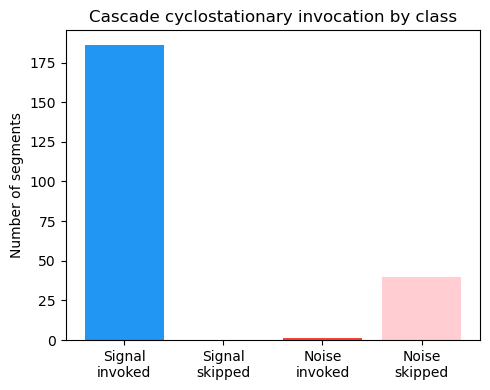

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
labels_bar = ["Signal\ninvoked", "Signal\nskipped", "Noise\ninvoked", "Noise\nskipped"]
values_bar = [
    cascade_stats["segments_cyclo_signal"],
    n_sig - cascade_stats["segments_cyclo_signal"],
    cascade_stats["segments_cyclo_noise"],
    n_noi - cascade_stats["segments_cyclo_noise"],
]
colors = ["#2196F3", "#90CAF9", "#F44336", "#FFCDD2"]
ax.bar(labels_bar, values_bar, color=colors)
ax.set_ylabel("Number of segments")
ax.set_title("Cascade cyclostationary invocation by class")
fig.tight_layout()
fig.savefig(OUT / "main_cyclo_invocation.png", dpi=150)
plt.show()

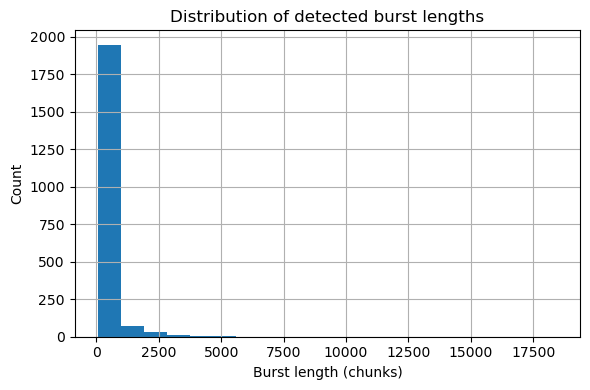

In [13]:
plt.figure(figsize=(6, 4))
plt.hist(cascade_stats["burst_lengths"], bins=20)
plt.xlabel("Burst length (chunks)")
plt.ylabel("Count")
plt.title("Distribution of detected burst lengths")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT / "main_burst_dist.png", dpi=150)
plt.show()